In [18]:
%matplotlib qt

import matplotlib.pyplot as plt

In [234]:
import sys
sys.path.insert(0, '.')

import numpy as np
import os

from config import NODES, EDGES, CALIBRATION_DATES, DATA_ROOT, calibration_path
from data_io import (
    load_session_df, load_sleap_dannce_keys, load_aligned_data,
    load_dannce_predictions, load_sleap_keys_3d,
)
from qc_utils import (
    find_sleap_dannce_alignment, compute_per_keypoint_distances,
    summarize_keypoint_distances, compute_session_qc_summary,
    track_distances_across_sessions, compute_temporal_alignment_quality,
    compute_keypoint_jitter, detect_tracking_dropouts,
    compute_bone_length_consistency,
    plot_per_keypoint_distances, plot_distance_over_time,
    plot_multi_session_distances, plot_temporal_alignment,
    generate_qc_video,
    test_calibration_epoch_effect, compute_days_since_calibration,
    plot_calibration_epoch_effect, plot_days_since_calibration,
    plot_snout_error_spatial_density,
)

import matplotlib.pyplot as plt
import scipy.io as sio

from sklearn.decomposition import PCA

from animations import animate_template

from config import NODES, EDGES, NODE_IDX
from data_io import (
    load_aligned_data, load_sleap_dannce_keys, load_template,
    load_behavior_log, load_session_df, load_frame_mapping, load_sleap_keys_3d,
    load_dannce_predictions,
)
from skeleton import normalize_skeleton_batch, project_to_pcs
from processing import get_template_match_indices, closest_indices

from scipy.ndimage import median_filter

In [249]:
%matplotlib inline

rat = 'R5'
session = '2026_06_09_1'
datapath = "/home/yutaka-sprague/olveczky_lab/Lab/CLIRB/data"
folder = f'{rat}/{session}'

keys = sio.loadmat(os.path.join(datapath, folder, 'processed', 'sleap_dannce_keys.mat'), simplify_cells=True)
aligned = sio.loadmat(os.path.join(datapath, folder, 'processed', 'aligned_data.mat'), simplify_cells=True)

#keys = load_sleap_dannce_keys(rat, session)
#aligned = load_aligned_data(rat, session)

aligned_indices = aligned['dannce_idx_for_sleap_cams'].astype(int).ravel()[1:]

sleap_3d = keys['sleap_keys_3D']
sleap_3d = median_filter(keys['sleap_keys_3D'], size=(11, 1, 1))
dannce_3d = keys['dannce_keys_3D']
if dannce_3d.ndim == 4:
    dannce_3d = dannce_3d.squeeze(axis=1).transpose(0, 2, 1)
else:
    
    dannce_3d = np.transpose(dannce_3d, [0,2,1])

dannce_3d = dannce_3d[aligned_indices, :,:]

dannce_3d = median_filter(dannce_3d, size=(11, 1, 1))

print(f'SLEAP: {sleap_3d.shape}, DANNCE: {dannce_3d.shape}')

SLEAP: (24000, 23, 3), DANNCE: (24000, 23, 3)


## Check SLEAP/DANNCE alignment

In [250]:
# Find best alignment (Procrustes on 10 random frames, tries z-flip automatically)
alignment = find_sleap_dannce_alignment(
    sleap_3d, dannce_3d, n_sample_frames=10, seed=42, try_z_flip=True
)

print(f"Alignment residual: {alignment['residual']:.2f} calibration units")
print(f"Z-flipped: {alignment['z_flipped']}")
print(f"Scale factor: {alignment['s']:.4f}")
print(f"Rotation matrix:\n{alignment['R']}")
print(f"Translation: {alignment['t']}")

# Apply alignment and compute distances
sleap_aligned = alignment['apply'](sleap_3d)
distances = compute_per_keypoint_distances(sleap_aligned, dannce_3d)
summary = summarize_keypoint_distances(distances)

print(f"Overall mean distance: {summary['overall_mean']:.2f} calibration units")
print(f"Overall median distance: {summary['overall_median']:.2f} calibration units")
print(f"Valid frames: {summary['n_valid_frames']}")

Alignment residual: 9.41 calibration units
Z-flipped: True
Scale factor: 1.0090
Rotation matrix:
[[ 1.76541303e-01 -9.84293030e-01  6.32146235e-04]
 [ 9.84269824e-01  1.76541497e-01  6.78326993e-03]
 [-6.78832536e-03 -5.75324849e-04  9.99976794e-01]]
Translation: [-22.59754681 175.94802386  -2.35703449]
Overall mean distance: 11.76 calibration units
Overall median distance: 9.40 calibration units
Valid frames: 24000


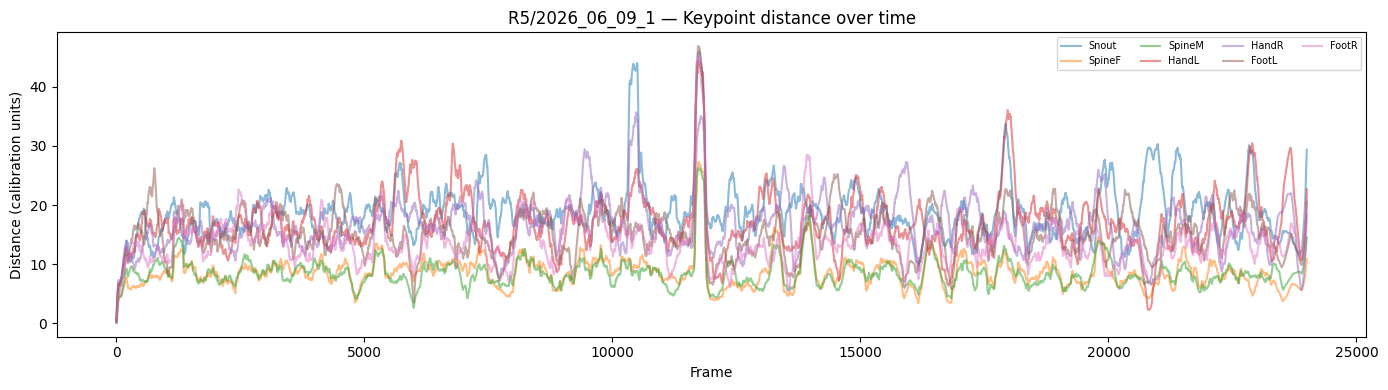

In [251]:
# Distance over time (rolling mean)
fig, ax = plt.subplots(figsize=(14, 4))
plot_distance_over_time(
    distances, 
    keypoint_indices=[0, 3, 4, 10, 14, 18, 22],  # Snout, SpineF, SpineM, HandL, HandR, FootL, FootR
    window=200, ax=ax,
    title=f'{rat}/{session} — Keypoint distance over time'
)
plt.tight_layout()
plt.show()

In [171]:
def _render_3d_panel(sleap_kp, dannce_kp, edges, panel_h, panel_w,
                     xyz_min, xyz_max, elev=25, azim=45):
    """
    Render a single 3D comparison frame to a numpy image using matplotlib.

    Returns (panel_h, panel_w, 3) uint8 BGR array.
    """
    dpi = 100
    fig_w = panel_w / dpi
    fig_h = panel_h / dpi
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    ax = fig.add_subplot(111, projection="3d")

    # SLEAP (cyan)
    ax.scatter(sleap_kp[:, 0], sleap_kp[:, 1], sleap_kp[:, 2],
               c="cyan", s=20, alpha=0.8, depthshade=True)
    for e in edges:
        ax.plot(sleap_kp[e, 0], sleap_kp[e, 1], sleap_kp[e, 2],
                "c-", lw=1.5, alpha=0.6)

    # DANNCE (magenta)
    ax.scatter(dannce_kp[:, 0], dannce_kp[:, 1], dannce_kp[:, 2],
               c="magenta", s=20, alpha=0.8, depthshade=True)
    for e in edges:
        ax.plot(dannce_kp[e, 0], dannce_kp[e, 1], dannce_kp[e, 2],
                "m-", lw=1.5, alpha=0.6)

    # Connecting lines
    for ki in range(len(sleap_kp)):
        ax.plot([sleap_kp[ki, 0], dannce_kp[ki, 0]],
                [sleap_kp[ki, 1], dannce_kp[ki, 1]],
                [sleap_kp[ki, 2], dannce_kp[ki, 2]],
                "k--", alpha=0.25, lw=0.5)

    ax.set_xlim(xyz_min[0], xyz_max[0])
    ax.set_ylim(xyz_min[1], xyz_max[1])
    ax.set_zlim(xyz_min[2], xyz_max[2])
    ax.set_xlabel("X", fontsize=7)
    ax.set_ylabel("Y", fontsize=7)
    ax.set_zlabel("Z", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title("3D Aligned", fontsize=9)

    fig.tight_layout(pad=0.5)
    fig.canvas.draw()

    # Convert to numpy array (compatible with newer matplotlib)
    img = np.array(fig.canvas.buffer_rgba())[:, :, :3]  # RGBA -> RGB
    plt.close(fig)

    # Resize to exact panel size and convert to BGR
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    if img_bgr.shape[0] != panel_h or img_bgr.shape[1] != panel_w:
        img_bgr = cv2.resize(img_bgr, (panel_w, panel_h))
    return img_bgr


def _draw_skeleton_2d(img, keypoints_2d, edges, color, radius=4, thickness=1):
    """Draw keypoints and skeleton edges on an image using OpenCV."""
    pts = keypoints_2d.astype(np.int32)
    for e in edges:
        p1 = tuple(pts[e[0]])
        p2 = tuple(pts[e[1]])
        cv2.line(img, p1, p2, color, thickness, cv2.LINE_AA)
    for i in range(len(pts)):
        cv2.circle(img, tuple(pts[i]), radius, color, -1, cv2.LINE_AA)

def generate_qc_video(rat, session, output_path, alignment_result=None,
                      n_frames=500, start_frame=0, fps=20,
                      camera_idx=1, alignment_n_frames=1000,
                      render_3d=True):
    """
    Generate a QC video using OpenCV for speed.

      Left panel: SLEAP camera video with SLEAP (cyan) and DANNCE (magenta)
                  keypoints overlaid. SLEAP points are projected directly;
                  DANNCE points are inverse-transformed to SLEAP space first.
      Right panel: 3D keypoints in aligned (DANNCE) space (rendered via
                   matplotlib per-frame). Set render_3d=False to skip this
                   panel for maximum speed.

    Parameters
    ----------
    rat : str
    session : str
    output_path : str — output .mp4 path
    alignment_result : dict — from find_sleap_dannce_alignment
    n_frames : int — number of frames to render
    start_frame : int — starting SLEAP frame
    fps : int — output video fps
    camera_idx : int — which SLEAP camera (default 1 = Camera1)
    alignment_n_frames : int — frames for Procrustes fit (default 1000)
    render_3d : bool — if True, include 3D comparison panel (slower).
                       If False, only render the 2D overlay (much faster).
    """
    import os
    from data_io import load_sleap_dannce_keys, load_aligned_data
    from projection import project_3d_to_2d_for_camera
    from config import sleap_path, calibration_path as get_cal_path

    print(f"Loading data for {rat}/{session}...")
    keys = sio.loadmat(os.path.join(datapath, folder, 'processed', 'sleap_dannce_keys.mat'), simplify_cells=True)
    aligned = sio.loadmat(os.path.join(datapath, folder, 'processed', 'aligned_data.mat'), simplify_cells=True)

    sleap_3d = keys["sleap_keys_3D"]
    dannce_3d = keys["dannce_keys_3D"]
    if dannce_3d.ndim == 4:
        dannce_3d = dannce_3d.squeeze(axis=1).transpose(0, 2, 1)
    else:
        dannce_3d = dannce_3d.transpose(0, 2, 1)

    sleap_3d = median_filter(keys['sleap_keys_3D'], size=(11, 1, 1))
    #dannce_3d = median_filter(keys['dannce_keys_3D'], size=(5, 1, 1))

    dannce_3d = median_filter(dannce_3d, size=(25, 1, 1))

    aligned_indices = aligned["dannce_idx_for_sleap_cams"].astype(int).ravel()

    # Compute alignment if not provided
    if alignment_result is None:
        print(f"Computing alignment with {alignment_n_frames} frames...")
        alignment_result = find_sleap_dannce_alignment(
            sleap_3d, dannce_3d, aligned_indices,
            n_sample_frames=alignment_n_frames,
        )
    print(f"Alignment residual: {alignment_result['residual']:.2f}")

    # For 3D panel: SLEAP in DANNCE space
    sleap_aligned = alignment_result["apply"](sleap_3d)

    # Open source video
    sp = sleap_path(rat, session)
    cam_name = f"Camera{camera_idx}"
    video_file = os.path.join(sp, cam_name, "0.mp4")
    cap = cv2.VideoCapture(video_file)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_file}")

    vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    cal_folder = get_cal_path(rat, session)

    end_frame = min(start_frame + n_frames, len(sleap_3d), len(aligned_indices))
    total_render = end_frame - start_frame

    # --- Pre-compute all 2D projections ---
    print("Projecting SLEAP keypoints to 2D...")
    sleap_2d = project_3d_to_2d_for_camera(
        sleap_3d[start_frame:end_frame], cal_folder, camera_idx=camera_idx
    )

    print("Transforming DANNCE to SLEAP space and projecting to 2D...")
    dannce_frames = []
    for i in range(start_frame, end_frame):
        di = aligned_indices[i] if i < len(aligned_indices) else 0
        if di < len(dannce_3d):
            dannce_frames.append(dannce_3d[di])
        else:
            dannce_frames.append(np.zeros((N_KEYPOINTS, 3)))
    dannce_frames_arr = np.array(dannce_frames)
    dannce_in_sleap = alignment_result["apply_inverse"](dannce_frames_arr)
    dannce_2d = project_3d_to_2d_for_camera(
        dannce_in_sleap, cal_folder, camera_idx=camera_idx
    )

    # --- Compute 3D axis limits for right panel ---
    if render_3d:
        sample_s = sleap_aligned[start_frame:end_frame]
        di_sample = aligned_indices[start_frame:end_frame]
        valid_di = di_sample[di_sample < len(dannce_3d)]
        sample_d = dannce_3d[valid_di] if len(valid_di) > 0 else sample_s
        all_pts = np.concatenate([sample_s.reshape(-1, 3), sample_d.reshape(-1, 3)])
        xyz_min = np.percentile(all_pts, 2, axis=0) - 20
        xyz_max = np.percentile(all_pts, 98, axis=0) + 20

    # --- Set up output video ---
    if render_3d:
        out_w = vid_w * 2
    else:
        out_w = vid_w
    out_h = vid_h

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Cannot open video writer for {output_path}")

    # Colors (BGR for OpenCV)
    CYAN = (255, 255, 0)
    MAGENTA = (255, 0, 255)
    WHITE = (255, 255, 255)

    print(f"Rendering {total_render} frames ({'with' if render_3d else 'without'} 3D panel)...")
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    for fi in range(total_render):
        frame_idx = start_frame + fi

        # Read video frame
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((vid_h, vid_w, 3), dtype=np.uint8)

        # Draw SLEAP skeleton (cyan)
        _draw_skeleton_2d(frame, sleap_2d[fi], EDGES, CYAN, radius=4, thickness=1)

        # Draw DANNCE skeleton (magenta)
        _draw_skeleton_2d(frame, dannce_2d[fi], EDGES, MAGENTA, radius=4, thickness=1)

        # Add text overlay
        cv2.putText(frame, f"Frame {frame_idx}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, WHITE, 2, cv2.LINE_AA)
        cv2.putText(frame, "SLEAP", (10, vid_h - 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, CYAN, 2, cv2.LINE_AA)
        cv2.putText(frame, "DANNCE", (10, vid_h - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, MAGENTA, 2, cv2.LINE_AA)

        if render_3d:
            # Render 3D panel
            s3d = sleap_aligned[frame_idx]
            di = aligned_indices[frame_idx] if frame_idx < len(aligned_indices) else 0
            d3d = dannce_3d[di] if di < len(dannce_3d) else s3d

            panel_3d = _render_3d_panel(
                s3d, d3d, EDGES, vid_h, vid_w, xyz_min, xyz_max
            )

            # Concatenate side by side
            combined = np.hstack([frame, panel_3d])
        else:
            combined = frame

        writer.write(combined)

        if (fi + 1) % 1000 == 0 or fi == total_render - 1:
            print(f"  {fi + 1}/{total_render} frames rendered")

    writer.release()
    cap.release()
    print(f"Saved to {output_path}")

In [172]:
import cv2

output_video = f'qc_video_{rat}_{session}.mp4'

generate_qc_video(
    rat, session,
    output_path=output_video,
    alignment_result=alignment,
    n_frames=1000,
    start_frame=7200,
    fps=20,
    camera_idx=1,  # Camera1
    render_3d = True
)

Loading data for R5/2026_06_09_1...
Alignment residual: 9.41
Projecting SLEAP keypoints to 2D...
Transforming DANNCE to SLEAP space and projecting to 2D...
Rendering 1000 frames (with 3D panel)...
  1000/1000 frames rendered
Saved to qc_video_R5_2026_06_09_1.mp4


SLEAP PCs: (24000, 69)
DANNCE PCs: (24000, 69)


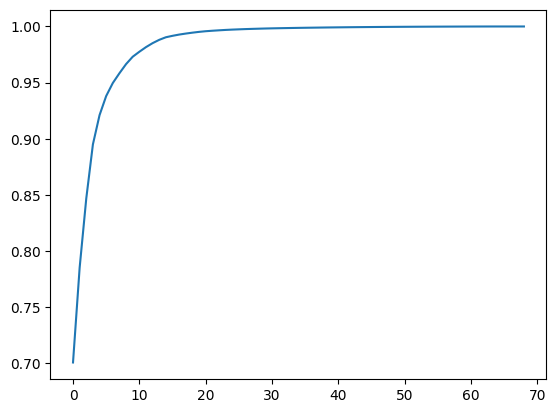

In [252]:
from skeleton import project_to_pcs

# SLEAP: flip z, normalize, project — using TEMPLATE feature_means.
sleap_flipped = sleap_3d.copy()
sleap_flipped[:, :, 2] = -sleap_flipped[:, :, 2]
sleap_rotated, _, _ = normalize_skeleton_batch(sleap_flipped)

# DANNCE: normalize, project (no z-flip; DANNCE is already in template coords).
dannce_rotated, _, _ = normalize_skeleton_batch(dannce_3d)

sleap_dannce_stack = np.vstack((sleap_rotated, dannce_rotated))
sleap_dannce_flat = np.reshape(sleap_dannce_stack, (sleap_dannce_stack.shape[0], 69))

sleap_flat = np.reshape(sleap_rotated, (sleap_rotated.shape[0], 69))
dannce_flat = np.reshape(dannce_rotated, (dannce_rotated.shape[0], 69))

feat_means = np.mean(sleap_dannce_flat, axis=0)
feat_std = np.std(sleap_dannce_flat, axis=0)

pca = PCA()
pca.fit(sleap_dannce_flat)

pc_weights = pca.components_
pc_explained_variance = pca.explained_variance_ratio_

sleap_means = np.mean(sleap_flat, axis=0)
dannce_means = np.mean(dannce_flat, axis=0)

sleap_pcs = project_to_pcs(sleap_rotated, pc_weights, feat_means)
dannce_pcs = project_to_pcs(dannce_rotated, pc_weights, feat_means)

print(f'SLEAP PCs: {sleap_pcs.shape}')
print(f'DANNCE PCs: {dannce_pcs.shape}')

fig = plt.figure()

plt.plot(np.cumsum(pc_explained_variance))

plt.show()


In [253]:
print(pca.explained_variance_ratio_)

[7.00852745e-01 8.44210577e-02 6.16644459e-02 4.80962677e-02
 2.60207923e-02 1.70062108e-02 1.16001280e-02 8.70971992e-03
 8.12897818e-03 6.55340444e-03 4.42769869e-03 4.12166168e-03
 3.55353614e-03 2.94963535e-03 2.28935687e-03 1.28056666e-03
 1.11286283e-03 9.00665885e-04 7.92752363e-04 7.12295960e-04
 5.79031877e-04 4.25910573e-04 3.76970719e-04 3.51435019e-04
 2.82467412e-04 2.38612889e-04 2.26828929e-04 1.83050137e-04
 1.71297901e-04 1.62834682e-04 1.34878654e-04 1.19270114e-04
 1.10976519e-04 1.02538055e-04 9.95902114e-05 8.94328550e-05
 8.29394103e-05 7.99677772e-05 7.74615467e-05 7.04747905e-05
 6.72408481e-05 6.43360089e-05 6.35894832e-05 5.65147350e-05
 5.20292971e-05 4.89845454e-05 4.58855025e-05 4.26199563e-05
 4.20358103e-05 3.69961890e-05 3.50509915e-05 3.35407763e-05
 2.86798911e-05 2.71577352e-05 2.58974675e-05 2.35966620e-05
 2.29069518e-05 2.11610750e-05 1.97523045e-05 1.90834634e-05
 1.74520674e-05 1.44879198e-05 1.18589859e-05 9.83363435e-06
 8.55584618e-06 1.701118

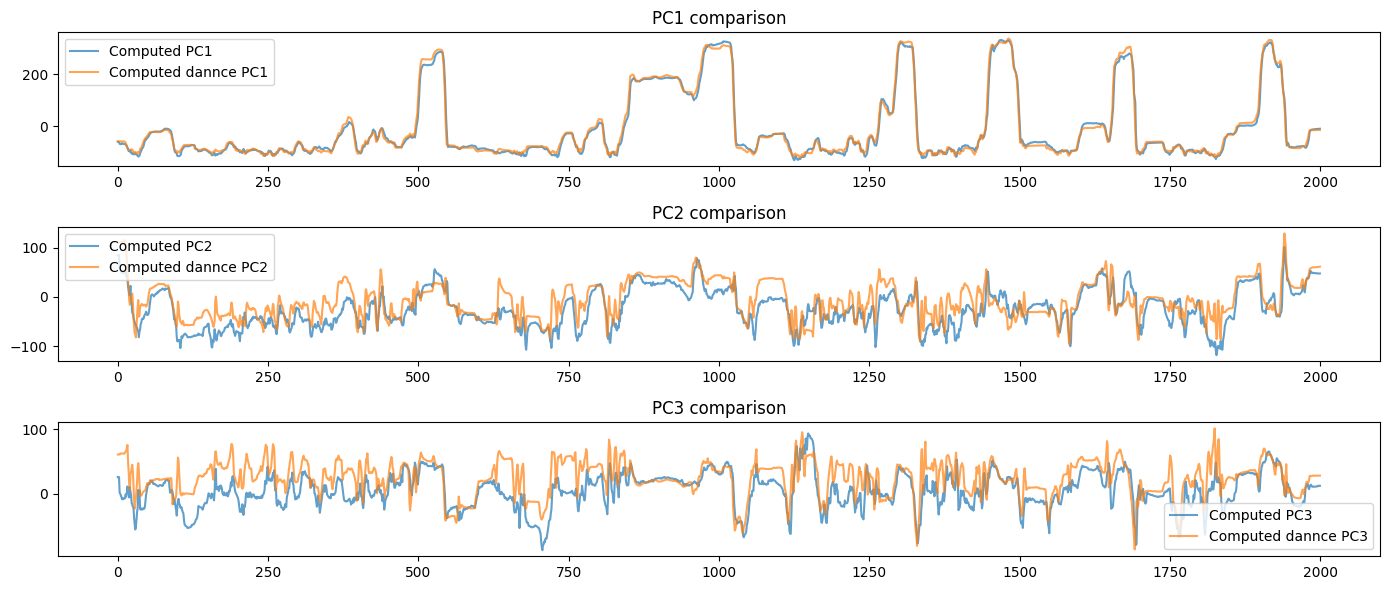

In [254]:
# If sleap_keys_PCs exists in the data, compare
#if 'sleap_keys_PCs' in keys:
    #stored_pcs = keys['sleap_keys_PCs']
fig, axes = plt.subplots(3, 1, figsize=(14, 6))
n_show = min(2000, len(sleap_pcs))

axes[0].plot(sleap_pcs[:n_show, 0], label='Computed PC1', alpha=0.7)
axes[0].plot(dannce_pcs[:n_show,0], label='Computed dannce PC1', alpha=0.7)
#axes[0].plot(stored_pcs[:n_show, 0], label='Stored PC1', alpha=0.7)
axes[0].legend()
axes[0].set_title('PC1 comparison')

axes[1].plot(sleap_pcs[:n_show, 1], label='Computed PC2', alpha=0.7) 
axes[1].plot(dannce_pcs[:n_show,1], label='Computed dannce PC2', alpha=0.7)
#axes[1].plot(stored_pcs[:n_show, 1], label='Stored PC2', alpha=0.7)
axes[1].legend()
axes[1].set_title('PC2 comparison')

axes[2].plot(sleap_pcs[:n_show, 2], label='Computed PC3', alpha=0.7)
axes[2].plot(dannce_pcs[:n_show,2], label='Computed dannce PC3', alpha=0.7)
#axes[1].plot(stored_pcs[:n_show, 1], label='Stored PC2', alpha=0.7)
axes[2].legend()
axes[2].set_title('PC3 comparison')

plt.tight_layout()
plt.show()

In [81]:
def get_keypoint_velocity(keys_3D_1, keys_3D_2):

    SpineF = keys_3D_1[3,:]
    SpineM = keys_3D_1[4,:]

    rotangle = np.arctan2( -(SpineF[1] - SpineM[1]), (SpineF[0] - SpineM[0]) )

    global_rotmat = np.zeros((2, 2))

    global_rotmat[0, 0] = np.cos(rotangle)
    global_rotmat[0, 1] = -np.sin(rotangle)
    global_rotmat[1, 0] = np.sin(rotangle)
    global_rotmat[1, 1] = np.cos(rotangle) 

    keys_1_centered = keys_3D_1 - SpineM 
    keys_2_centered = keys_3D_2 - SpineM 

    keys_1_rotated = keys_1_centered 
    keys_2_rotated = keys_2_centered 

    keys_1_rotated[:,:2] = np.transpose(global_rotmat @ np.transpose(keys_1_rotated[:,:2]))
    keys_2_rotated[:,:2] = np.transpose(global_rotmat @ np.transpose(keys_2_rotated[:,:2]))

    key_1_COM = np.mean(keys_1_rotated[3:5,:2], axis=0)
    key_2_COM = np.mean(keys_2_rotated[3:5,:2], axis=0)

    return key_2_COM-key_1_COM, global_rotmat # velocity centered on 

def get_COM_vel(keys_3D, sleap=False):
    COM_vel = np.zeros((keys_3D.shape[0], 2))

    for i in range(keys_3D.shape[0]):
        if i ==0:
            continue
        else:
            velocity, rotmat = get_keypoint_velocity(np.squeeze(keys_3D[i-1,:,:]), np.squeeze(keys_3D[i,:,:]))

            COM_vel[i,:] = velocity

    return COM_vel

dannce_COM_vel = get_COM_vel(dannce_3d)

## Fine tune SLEAP/DANNCE models and add corrections

In [ ]:
# ---- Toggle ---------------------------------------------------------------
APPLY_CORRECTOR  = True
# v4 with the reprojection-residual channel — current best across R1/R2/R3.
# Combined with --smooth_size 15 the single-model F1xyz is 0.870/0.804/0.840
# on the test split (rebuild template active). The model needs per-frame 2D +
# confidence + reprojection-residual features in addition to the pose window,
# all of which `correct_temporal_mlp_2d_reproj` builds internally from
# `load_session_2d`. The Procrustes fit also has to use that loader's
# (x_triang_3d, y_dannce_3d) to match the training-time alignment exactly.
CORRECTOR_CKPT   = 'corrector/checkpoints/R1R2R3_temporal_mlp_2d_reproj_v4_dn2sl.pt'
SMOOTH_SIZE      = 5        # production-recommended (offline)
SMOOTH_CAUSAL    = 5     # True for online causal mode (size 5-7)
CALIBRATION_MIN  = 5.0       # minutes of pre-task data for the Procrustes fit
MAX_PROCRUSTES_RESIDUAL = 60.0   # mm; abort if SLEAP/DANNCE aren't co-calibrated
# ---------------------------------------------------------------------------

if APPLY_CORRECTOR:
    import sys, os, importlib
    sys.path.insert(0, os.path.abspath('.'))
    sys.path.insert(0, os.path.abspath('experiments'))

    # Force-reload modules in dependency order in case the kernel cached
    # older copies. Two things have been hit during development:
    #   1. `corrector.models` was cached without `temporal_mlp_2d_reproj`
    #      in `build_model`, causing a ValueError on instantiation.
    #   2. `config.processed_path` was cached without the SMB fallback,
    #      causing FileNotFoundError on new rats (R4/R5/R6) where the
    #      local cache has no entry.
    # Reloading in this exact order is important — every dependent module
    # holds *bound references* to the symbols it imported (`from config0.34
    # import sleap_path`, etc.). Reloading `config` alone re-evaluates the
    # function bodies in `config`, but the `sleap_path` *name* inside
    # `data_io` still points at the old function object. We have to reload
    # consumers too so they re-bind to the new function.
    for _modname in (
        'config',
        'data_io',
        'corrector.world_alignment',
        'corrector.data_world_2d',
        'corrector.data_world_2d_from_saved',
        'corrector.models',
        'corrector.evaluate_all',
    ):
        if _modname in sys.modules:
            importlib.reload(sys.modules[_modname])

    import torch, numpy as np
    from corrector.world_alignment import calibration_indices, fit_procrustes
    from corrector.models import build_model
    from corrector.data_world_2d_from_saved import load_session_2d
    from corrector.evaluate_all import correct_temporal_mlp_2d_reproj

    # Quick sanity check that the reloads stuck — print which path
    # config.processed_path returns for this rat/session so any future
    # cache-miss is immediately visible.
    from config import processed_path as _pp, sleap_path as _sp
    print(f'processed_path -> {_pp(rat, session)}')
    print(f'sleap_path     -> {_sp(rat, session)}')

    # ---- Load the checkpoint ---------------------------------------------
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ck = torch.load(CORRECTOR_CKPT, map_location=device, weights_only=False)
    model_kwargs = dict(ctx=ck.get('ctx', 5),
                        hidden=ck.get('hidden', 128),
                        n_hidden_layers=ck.get('n_hidden_layers', 2),
                        dropout=ck.get('dropout', 0.0))
    model = build_model(ck['model_name'], **model_kwargs)
    model.load_state_dict(ck['state_dict'])
    model = model.to(device).eval()
    eval_ctx = ck.get('ctx', 5)
    procrustes_direction = ck.get('procrustes_direction', 'sleap_to_dannce')
    assert ck['model_name'] == 'temporal_mlp_2d_reproj', \
        f"This block expects a temporal_mlp_2d_reproj checkpoint; got {ck['model_name']}"
    print(f'Loaded corrector: {ck["model_name"]}  ctx={eval_ctx}  '
          f'tag={ck.get("tag")}  best_val_mse={ck.get("best_val_mse"):.2f}')

    # ---- Procrustes fit on the calibration epoch -------------------------
    # Use load_session_2d's (x_triang_3d, y_dannce_3d) for the fit — these are
    # the un-smoothed triangulated SLEAP indexed by processed_frame, paired
    # against DANNCE through the saved frame_mapping. This is exactly what the
    # trainer used; using the notebook's median-filtered `sleap_3d` here would
    # not match training-time alignment.
    sd = load_session_2d(rat, session, smooth_dannce=True)
    cal_idx = calibration_indices(len(sd.x_triang_3d), CALIBRATION_MIN,
                                   sleap_hz=20.0, n_sample=1000, seed=0)
    if procrustes_direction == 'dannce_to_sleap':
        tx = fit_procrustes(sd.y_dannce_3d[cal_idx], sd.x_triang_3d[cal_idx],
                            try_z_flip=True)
    else:
        tx = fit_procrustes(sd.x_triang_3d[cal_idx], sd.y_dannce_3d[cal_idx],
                            try_z_flip=True)
    print(f'Procrustes residual: {tx["residual"]:.2f} mm  scale={tx["s"]:.4f}  '
          f'z_flipped={tx["z_flipped"]}  direction={procrustes_direction}')
    if tx['residual'] > MAX_PROCRUSTES_RESIDUAL:
        raise RuntimeError(
            f'Procrustes residual {tx["residual"]:.1f} mm exceeds threshold '
            f'{MAX_PROCRUSTES_RESIDUAL} mm — SLEAP and DANNCE may be uncalibrated. '
            f'Skip the corrector for this session.')

    # ---- Run the corrector ----------------------------------------------
    # The reproj corrector wants its input in the corrector's native frame:
    # DANNCE world for the legacy SL->DN convention, SLEAP world for DN->SL.
    # `sleap_3d` is the notebook's median-11 SLEAP-world array on the SLEAP
    # timeline; this matches what the model's pose_window expects.
    sleap_world = sleap_3d.astype(np.float32)
    if procrustes_direction == 'dannce_to_sleap':
        sl_aligned = sleap_world                                # already in SLEAP / corrector frame
    else:
        sl_aligned = tx['apply'](sleap_world).astype(np.float32)
    sl_corrected_native = correct_temporal_mlp_2d_reproj(
        model, rat, session, sl_aligned, device,
        ctx=eval_ctx, smooth_size=SMOOTH_SIZE,
        smooth_causal=SMOOTH_CAUSAL)
    # Bring back to SLEAP world for downstream cells (PC projection,
    # template matching, etc.). apply_inverse is the identity under dn2sl.
    if procrustes_direction == 'dannce_to_sleap':
        sleap_corrected_world = sl_corrected_native.astype(np.float32)
    else:
        sleap_corrected_world = tx['apply_inverse'](sl_corrected_native).astype(np.float32)

    # ---- Replace sleap_3d so downstream uses corrected keypoints ---------
    sleap_3d_uncorrected = sleap_3d.copy()   # keep a copy in case you want to compare
    sleap_3d_corrected = sleap_corrected_world
    print(f'sleap_3d replaced with corrected keypoints. Original kept as sleap_3d_uncorrected. '
          f'smooth_size={SMOOTH_SIZE} causal={SMOOTH_CAUSAL}')
else:
    print('Corrector skipped (APPLY_CORRECTOR=False).')

processed_path -> /home/yutaka-sprague/olveczky_lab/Lab/CLIRB/data/R6/2026_06_08_1/processed
sleap_path     -> /home/yutaka-sprague/olveczky_lab/Lab/CLIRB/data/R6/2026_06_08_1/sleap
Loaded corrector: temporal_mlp_2d_reproj  ctx=5  tag=R1R2R3_temporal_mlp_2d_reproj_v4_dn2sl  best_val_mse=138.16
Procrustes residual: 16.10 mm  scale=1.0015  z_flipped=True  direction=dannce_to_sleap
sleap_3d replaced with corrected keypoints. Original kept as sleap_3d_uncorrected. smooth_size=5 causal=5


In [148]:
%matplotlib qt 

In [149]:
sleap_flipped_corr = sleap_3d_corrected.copy()
sleap_flipped_corr[:, :, 2] = -sleap_flipped_corr[:,:,2]
sleap_rotated_corr, _, _ = normalize_skeleton_batch(sleap_flipped_corr)
sleap_flat_corr = np.reshape(sleap_rotated_corr, (sleap_rotated_corr.shape[0], 69))

sleap_pcs_corr = project_to_pcs(sleap_rotated_corr, pc_weights, feat_means)

fig, axes = plt.subplots(3, 1, figsize=(14, 6))
n_show = min(2000, len(sleap_pcs))

axes[0].plot(sleap_pcs[:n_show, 0], label='Computed SLEAP PC1', alpha=0.7)
axes[0].plot(dannce_pcs[:n_show,0], label='Computed DANNCE PC1', alpha=0.7)
axes[0].plot(sleap_pcs_corr[:n_show, 0], label='Corrected SLEAP PC1', alpha=0.7)
axes[0].legend()
axes[0].set_title('PC1 comparison')

axes[1].plot(sleap_pcs[:n_show, 1], label='Computed SLEAP PC2', alpha=0.7) 
axes[1].plot(dannce_pcs[:n_show,1], label='Computed DANNCE PC2', alpha=0.7)
axes[1].plot(sleap_pcs_corr[:n_show, 1], label='Corrected SLEAP PC2', alpha=0.7)
axes[1].legend()
axes[1].set_title('PC2 comparison')
#axes[1].set_ylim((-50,100))

axes[2].plot(sleap_pcs[:n_show, 2], label='Computed SLEAP PC3', alpha=0.7)
axes[2].plot(dannce_pcs[:n_show,2], label='Computed DANNCE PC3', alpha=0.7)
axes[2].plot(sleap_pcs_corr[:n_show, 2], label='Corrected SLEAP PC3', alpha=0.7)
axes[2].legend()
axes[2].set_title('PC3 comparison')

plt.tight_layout()
plt.show()

## Extract motifs from baseline sessions

Scan through session to identify motifs
Once template selected, search for matches in session
Set template as average of identified matches across baseline sessions
Save matched template

In [7]:
def sliding_windows(keypoints, win=30, step=10):
    # keypoints: (T, K, 3) or (K, 3, T) - we'll accept both
    kp = np.asarray(keypoints)
    if kp.ndim == 3 and kp.shape[0] == 3:  # maybe (3, K, T)
        kp = np.transpose(kp, (2,1,0))
    if kp.ndim == 3 and kp.shape[1] == 3 and kp.shape[2] != 3:
        # likely (T, K, 3)
        pass
    T, K, D = kp.shape
    windows = []
    idxs = []
    for start in range(0, T - win + 1, step):
        w = kp[start:start+win]  # shape (win, K, 3)
        windows.append(w)
        idxs.append(start)
    return np.array(windows), np.array(idxs)  # (n_windows, win, K, 3)

def mean_speed_of_window(window):
    # window: (win, K, 3)
    # compute speed per keypoint per frame, average
    diffs = np.diff(window, axis=0)  # (win-1, K, 3)
    speeds = np.linalg.norm(diffs, axis=2)  # (win-1, K)
    return speeds.mean()

def get_candidates(keys_3D, features, win_size=30, step=10, mov_thresh=1.0):

    windows, starts = sliding_windows(keys_3D, win=win_size, step=step)

    speeds = np.array([mean_speed_of_window(w) for w in windows])
    
    keep_mask = speeds >= mov_thresh
    kept_windows = windows[keep_mask]
    kept_starts = starts[keep_mask]
    print(f"Total windows: {len(windows)}, kept (moving): {len(kept_windows)}")

    return kept_starts

features_dannce = np.hstack((dannce_pcs, dannce_COM_vel))

candidates = get_candidates(dannce_3d, features_dannce, mov_thresh=2.5) #candidates should return frame indexes and template for each potential candidate, should also save each motif to a folder

NameError: name 'dannce_COM_vel' is not defined

In [160]:
from collections import deque

def check_template_match(pc_buffer, pc_template, pc_template_bounds):
    """
    Check if PC values in buffer match the template within specified bounds.
    
    Parameters:
    - pc_buffer: Array of PC values, shape (buffer_length, n_components)
    - pc_template: Template PC trajectory, shape (template_length, n_components)
    - pc_template_bounds: Tolerance bounds for each PC dimension
    
    Returns:
    - True if buffer matches template within bounds, False otherwise
    """
    pc_array = np.array(pc_buffer)
    
    # Check how many points fall outside the bounds
    outside_bounds = (pc_array >= pc_template + pc_template_bounds) | (pc_array <= pc_template - pc_template_bounds)
    
    # If fewer than 3 points are outside bounds, consider it a match
    num_outside = np.sum(outside_bounds)
    
    return num_outside <= 3, num_outside


def get_template_match_indices(keys_pcs, pc_template, pc_template_bounds, refractory_frames=None):
    """
    Search through PC data to find frames matching a behavioral template.
    
    Parameters:
    - keys_pcs: Full PC trajectory data, shape (n_frames, n_components)
    - pc_template: Template PC trajectory to match, shape (template_length, n_components)
    - pc_template_bounds: Tolerance bounds for matching, same shape as pc_template
    - refractory_frames: Minimum frames between matches (default: template_length)
    
    Returns:
    - match_idxs: List of frame indices where template matches were found
    """
    buffer = deque()
    template_length = pc_template.shape[0]
    match_idxs = []
    num_outside = np.full(keys_pcs.shape[0], np.nan)
    
    # Set refractory period to template length if not specified
    if refractory_frames is None:
        refractory_frames = template_length
    
    last_match = -refractory_frames
        
    # Slide through all frames
    for i in range(keys_pcs.shape[0]):
        # Add current frame's PC values to buffer
        buffer.append(keys_pcs[i, :])
        
        # Remove old frames that exceed template length
        while buffer and len(buffer) > template_length:
            buffer.popleft()
        
        # Wait until buffer is full before checking
        if len(buffer) < template_length:
            continue
        
        # Check if buffer matches template AND refractory period has passed
        is_match, num_outside[i] = check_template_match(buffer, pc_template, pc_template_bounds)
        if is_match and (i - last_match >= refractory_frames):
            match_idxs.append(i)
            last_match = i
    
    return match_idxs, num_outside

In [41]:
def check_motifs(folder, keys_3D, features, candidates, pc_idxs, com_idxs, feature_means, feature_stds, bounds, win_size=30):

    save_folder = os.path.join(datapath, folder, 'motifs')
    
    pcs_use = features[:,pc_idxs]
    coms_use = features[:, com_idxs]
    stds_use = feature_stds[pc_idxs]

    good_motifs = {}

    prev_start = None 

    for start in candidates:

        if not prev_start:
            prev_start= start
        elif not start>prev_start +30:
            continue

        template = pcs_use[start:start+win_size]
        template_full = features[start:start+win_size]

        match_idxs, num_outside = get_template_match_indices(pcs_use, template, stds_use*bounds)

        if len(match_idxs)>5 and len(match_idxs)<50:
            prev_start = start
            print(f'Got {len(match_idxs)} matches for window starting at frame {start}')

            animate_template(keys_3D[start:start+30], template_full, feature_stds*bounds, feature_means, 20, 30, save_folder, f'frame_{start}_matches_{len(match_idxs)}', flip_skel=True)

            good_motifs[start] = match_idxs

    return good_motifs

In [42]:
good_motifs = check_motifs(folder, dannce_3d, features_dannce, candidates, [0,1], [2], feat_means, feat_std, 1.0, win_size=30)

Got 6 matches for window starting at frame 9740
Got 6 matches for window starting at frame 20420
Got 6 matches for window starting at frame 22110
Got 7 matches for window starting at frame 22190
Got 6 matches for window starting at frame 23350


In [ ]:
def save_checked_matches(idxs_to_check, features, check_folder, pcs_to_use, bounds, template_params):
    feature_stds = template_params['feature_stds']
    feature_means = template_params['feature_means']

    video_path = os.path.join(datapath, check_folder, 'sleap', 'camera1', '0.mp4')

    for temp_idx in idxs_to_check:

        output_vid_path = os.path.join(datapath, check_folder, 'sleap', f'template_matches_{temp_idx}.mp4')

        template_check = features[temp_idx:temp_idx+30,:]

        match_idxs, num_outside = get_template_match_indices(features_sleap[:,pcs_to_use], template_check[:,pcs_to_use], feature_stds[np.newaxis,[pcs_to_use]]*bounds, COM_dannce[:,0])

        print(match_idxs)

        save_template_matches_video(match_idxs, template_check, feature_stds[np.newaxis,:]*bounds, sleap_3D, features_sleap, edges, video_path, output_vid_path, max_matches=20)

## Evaluate overlap between SLEAP and DANNCE identified matches across motifs

In [255]:
template_file = 'template_199.npz'
n_components = 2  # number of PCs for template matching

# Load template
template_data = load_template(rat, template_file)
pc_template = template_data['template'][:,:n_components]  # (template_length, n_components)
pc_weights = template_data['pc_weights']  # (n_pcs, n_features)
feature_means = template_data['feature_means']
bounds = float(template_data['bounds'])
pcs_to_use = template_data['pcs_to_use']

template_filt = median_filter(pc_template, size=(5,1))

template_length = pc_template.shape[0]
print(f'Template length: {template_length} frames')
print(f'Bounds: {bounds}')
print(f'PCs used: {pcs_to_use}')

# Template bounds: uniform bounds applied per PC per timepoint      
feature_stds = template_data['feature_stds']
pc_template_bounds = np.ones_like(pc_template) * bounds * feature_stds[:n_components]

Template length: 30 frames
Bounds: 1.0
PCs used: [0 1]


In [222]:
template_data.keys()
pc_template_bounds = template_data['bounds_to_use']

In [206]:
print(template_data['temp_origin_file'])
print(template_data['temp_origin_idx'])

R4/R4\2026_06_09_1
21040


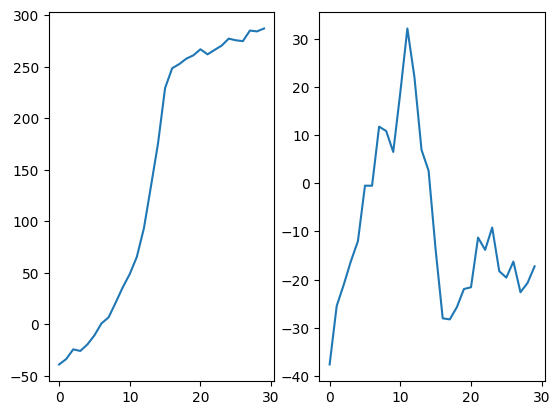

(30, 2)
(30, 2)


In [256]:
origin_idx = template_data['temp_origin_idx']

fig, axs = plt.subplots(1,2)
#pc_template = sleap_pcs[origin_idx:origin_idx+30,:2]

axs[0].plot(pc_template[:,0])
axs[1].plot(pc_template[:,1])

#axs[1].set_ylim((-20,80))

plt.show()

print(pc_template.shape)
print(pc_template_bounds.shape)

In [223]:
sleap_pcs_use = project_to_pcs(sleap_rotated, pc_weights, feature_means)
dannce_pcs_use = project_to_pcs(dannce_rotated, pc_weights, feature_means)

In [257]:
# Run offline matching on SLEAP PCs
sleap_matches, num_outside = get_template_match_indices(
    sleap_pcs[:,:n_components], pc_template, pc_template_bounds, refractory_frames=template_length
    #sleap_pcs[:,:n_components], template_filt, pc_template_bounds, refractory_frames=template_length
    #sleap_pcs[:,:n_components], sleap_template_pcs[:,:2], pc_template_bounds, refractory_frames=template_length
)
print(f'SLEAP offline matches: {len(sleap_matches)}')

# Run offline matching on DANNCE PCs

dannce_matches, num_outside = get_template_match_indices(
    dannce_pcs[:,:n_components], pc_template, pc_template_bounds, refractory_frames=template_length
    #dannce_pcs[:,:n_components], template_filt, pc_template_bounds, refractory_frames=template_length
    #dannce_pcs[:,:n_components], dannce_template_pcs[:,:2], pc_template_bounds, refractory_frames=template_length
)
print(f'DANNCE offline matches: {len(dannce_matches)}')

SLEAP offline matches: 41
DANNCE offline matches: 36


In [27]:
pc_template_bounds

array([[122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
       [122.11031762,  43.43661171],
 

In [154]:
print(sleap_matches)
print(sleap_matches_new)

[105, 3902, 3999, 7370, 7673, 10840, 16337, 22311]
[3490, 3753, 6728, 7376, 7432, 9297, 11247, 11776, 12216, 13133, 13985, 15273, 20970, 21066]


In [260]:
sleap_match_pcs = np.array([sleap_pcs[match-30+1:match+1,:2] for match in sleap_matches])
sleap_rebuild_template = np.mean(sleap_match_pcs, axis=0)
sleap_rebuild_std = np.std(sleap_match_pcs, axis=0)

dannce_match_pcs = np.array([dannce_pcs[match-30+1:match+1,:2] for match in sleap_matches])
dannce_rebuild_template = np.mean(dannce_match_pcs, axis=0)
dannce_rebuild_std = np.std(dannce_match_pcs, axis=0)

sleap_matches_new, num_outside = get_template_match_indices(
    sleap_pcs[:,:n_components], sleap_rebuild_template, sleap_rebuild_std*2, refractory_frames=template_length
    #sleap_pcs[:,:n_components], template_filt, pc_template_bounds, refractory_frames=template_length
    #sleap_pcs[:,:n_components], sleap_template_pcs[:,:2], pc_template_bounds, refractory_frames=template_length
)

dannce_matches_new, num_outside = get_template_match_indices(
    dannce_pcs[:,:n_components], dannce_rebuild_template, dannce_rebuild_std*2, refractory_frames=template_length
    #dannce_pcs[:,:n_components], template_filt, pc_template_bounds, refractory_frames=template_length
    #dannce_pcs[:,:n_components], dannce_template_pcs[:,:2], pc_template_bounds, refractory_frames=template_length
)

print(len(sleap_matches_new))
print(len(dannce_matches_new))

35
41


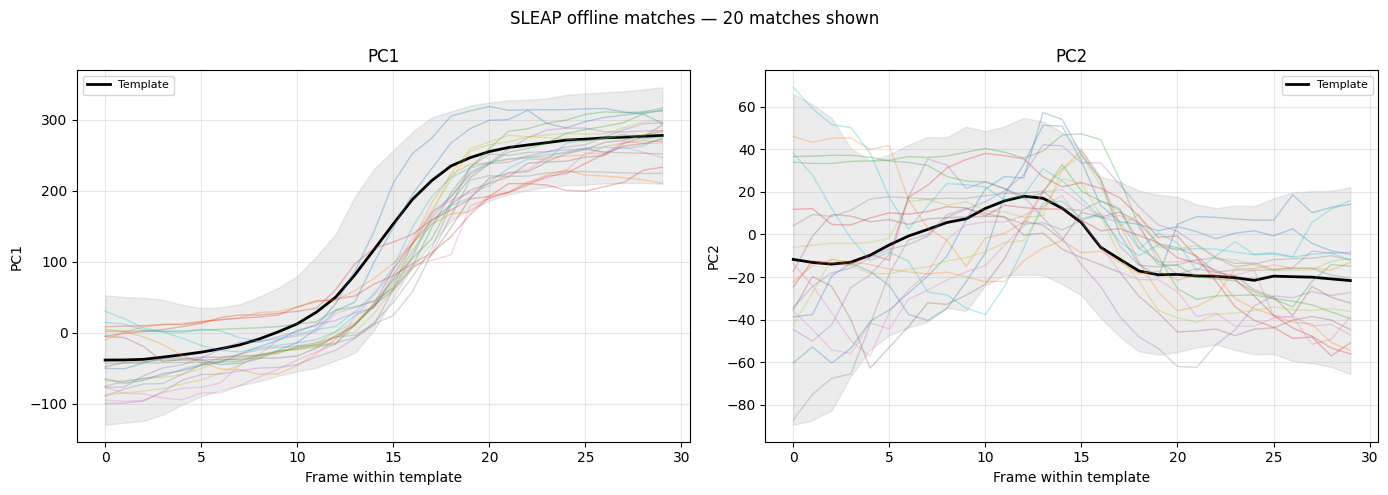

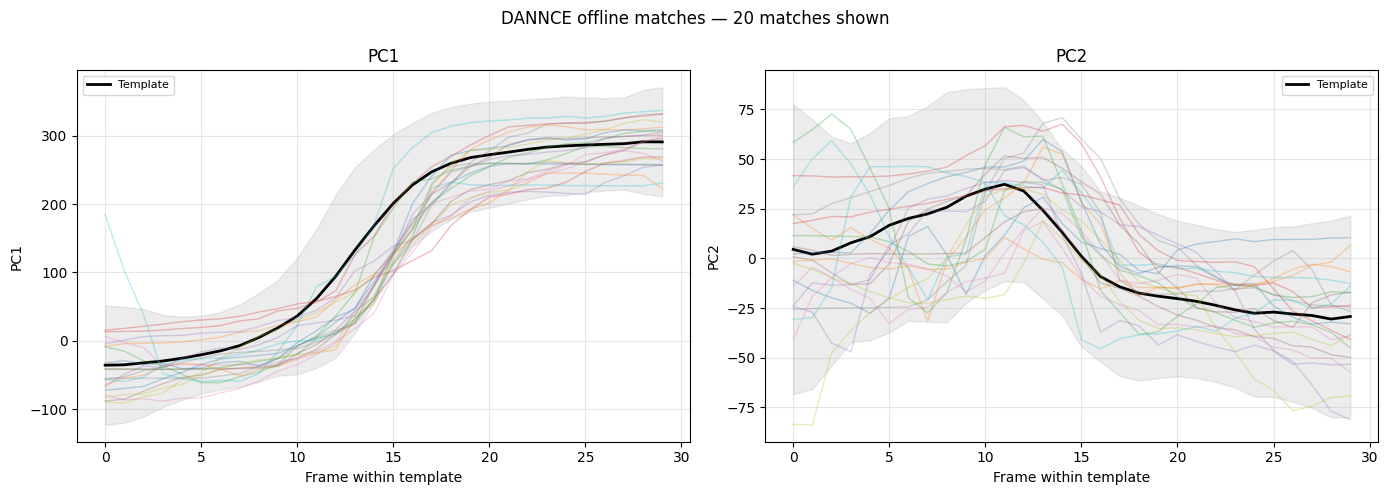

In [261]:
def plot_template_matches(pcs, match_indices, pc_template, pc_template_bounds,
                          n_components=2, title='', max_matches=20):
    """Plot matched PC trajectories against the template."""
    template_length = pc_template.shape[0]
    n_show = min(len(match_indices), max_matches)
    
    fig, axes = plt.subplots(1, n_components, figsize=(7 * n_components, 5))
    if n_components == 1: 
        axes = [axes]
    
    t_axis = np.arange(template_length)
    
    for pc in range(n_components):
        ax = axes[pc]
        # Template and bounds
        ax.plot(t_axis, pc_template[:, pc], 'k-', linewidth=2, label='Template')
        ax.fill_between(t_axis,
                        pc_template[:, pc] - pc_template_bounds[:, pc],
                        pc_template[:, pc] + pc_template_bounds[:, pc],
                        alpha=0.15, color='gray')
        
        # Matched trajectories
        for mi in match_indices[:n_show]:
            start = mi - template_length + 1
            if start < 0:
                continue
            segment = pcs[start:mi + 1, pc]
            ax.plot(t_axis[:len(segment)], segment, alpha=0.3, linewidth=1)
        
        ax.set_xlabel('Frame within template')
        ax.set_ylabel(f'PC{pc + 1}')
        ax.set_title(f'PC{pc + 1}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{title} — {n_show} matches shown', fontsize=12)
    plt.tight_layout()
    plt.show()


#plot_template_matches(sleap_pcs, sleap_matches, template_filt, pc_template_bounds,
#                      n_components=n_components, title='SLEAP offline matches')

plot_template_matches(sleap_pcs, sleap_matches_new, sleap_rebuild_template, sleap_rebuild_std*2,
                      n_components=n_components, title='SLEAP offline matches')


#plot_template_matches(dannce_pcs, dannce_matches, template_filt, pc_template_bounds,
#                      n_components=n_components, title='DANNCE offline matches')


plot_template_matches(dannce_pcs, dannce_matches_new, dannce_rebuild_template, dannce_rebuild_std*2,
                      n_components=n_components, title='DANNCE offline matches')

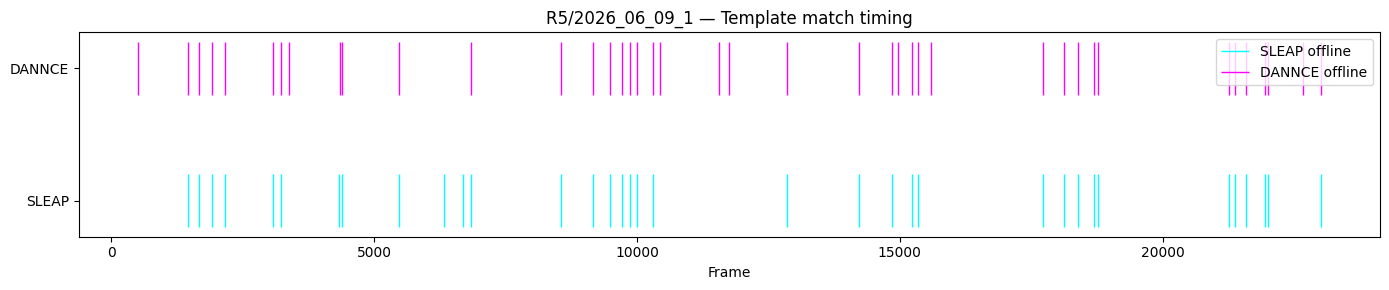

In [262]:
# Plot match times over the session
fig, ax = plt.subplots(figsize=(14, 3))

if len(sleap_matches) > 0:
    ax.vlines(np.array(sleap_matches_new), 0.8, 1.2, colors='cyan', linewidth=1, label='SLEAP offline')

if len(dannce_matches) > 0:
    ax.vlines(np.array(dannce_matches_new), 1.8, 2.2, colors='magenta', linewidth=1, label='DANNCE offline')
ax.set_yticks([1, 2])
ax.set_yticklabels(['SLEAP', 'DANNCE'])
ax.set_xlabel('Frame') 

ax.set_title(f'{rat}/{session} — Template match timing')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [263]:
def closest_match(source_indices, target_indices):
    """
    For each t in target_times, return the index of the closest value in source_times.
    Returns empty array if source_times is empty.
    """

    return np.array([np.argmin(np.abs(np.array(source_indices)-t)) for t in target_indices])

def get_match_overlap(dannce_matches, sleap_matches, thresh=10):

    sleap_only = []
    dannce_only = []
    both = []

    if len(dannce_matches) == 0 and len(sleap_matches) == 0:
        return np.array(sleap_only), np.array(dannce_only), np.array(both)
    elif len(dannce_matches) == 0:
        return np.array(sleap_matches), np.array(dannce_only), np.array(both)
    elif len(sleap_matches) == 0:
        return np.array(sleap_only), np.array(dannce_matches), np.array(both)
    else:

        close_match_sleap = closest_match(dannce_matches, sleap_matches)
        close_match_dannce = closest_match(sleap_matches, dannce_matches)

        both = np.array(sleap_matches)[np.where(np.abs(np.array(sleap_matches) - np.array(dannce_matches)[close_match_sleap])<thresh)]
        sleap_only = np.array(sleap_matches)[np.where(np.abs(np.array(sleap_matches) - np.array(dannce_matches)[close_match_sleap])>=thresh)]
        dannce_only = np.array(dannce_matches)[np.where(np.abs(np.array(dannce_matches) - np.array(sleap_matches)[close_match_dannce])>=thresh)]
        
        return sleap_only, dannce_only, both

#sleap_only, dannce_only, both = get_match_overlap(dannce_matches, sleap_matches)
sleap_only, dannce_only, both = get_match_overlap(dannce_matches_new, sleap_matches_new)

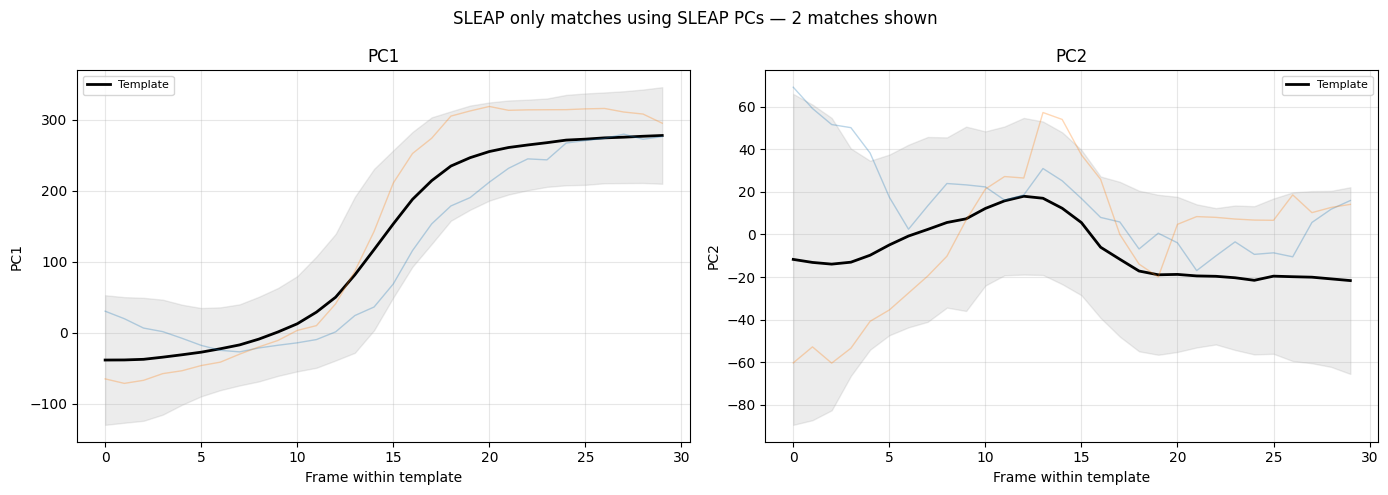

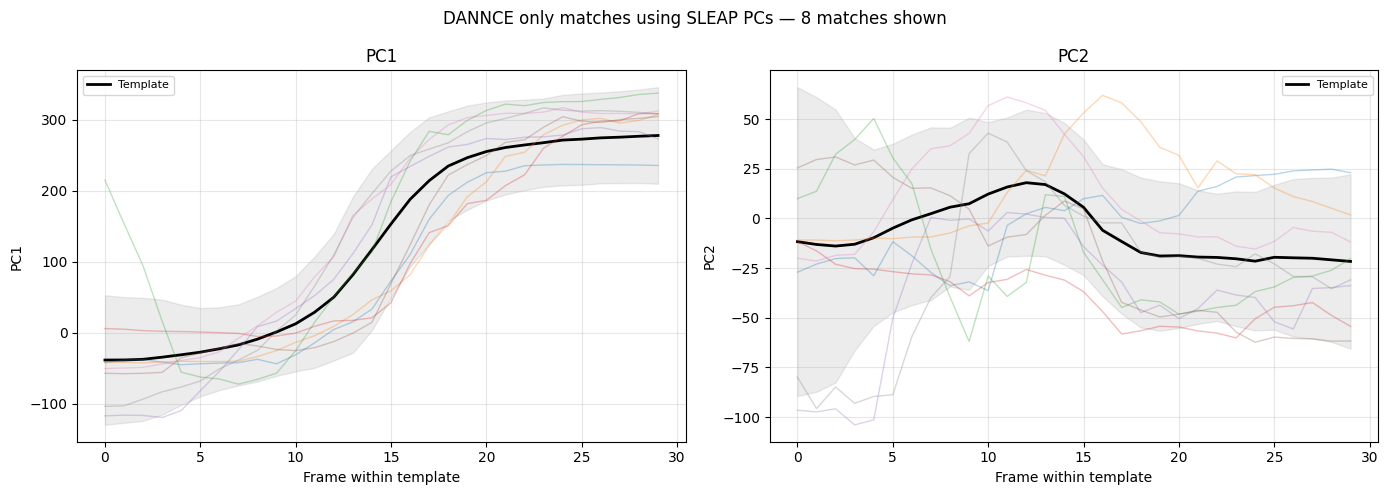

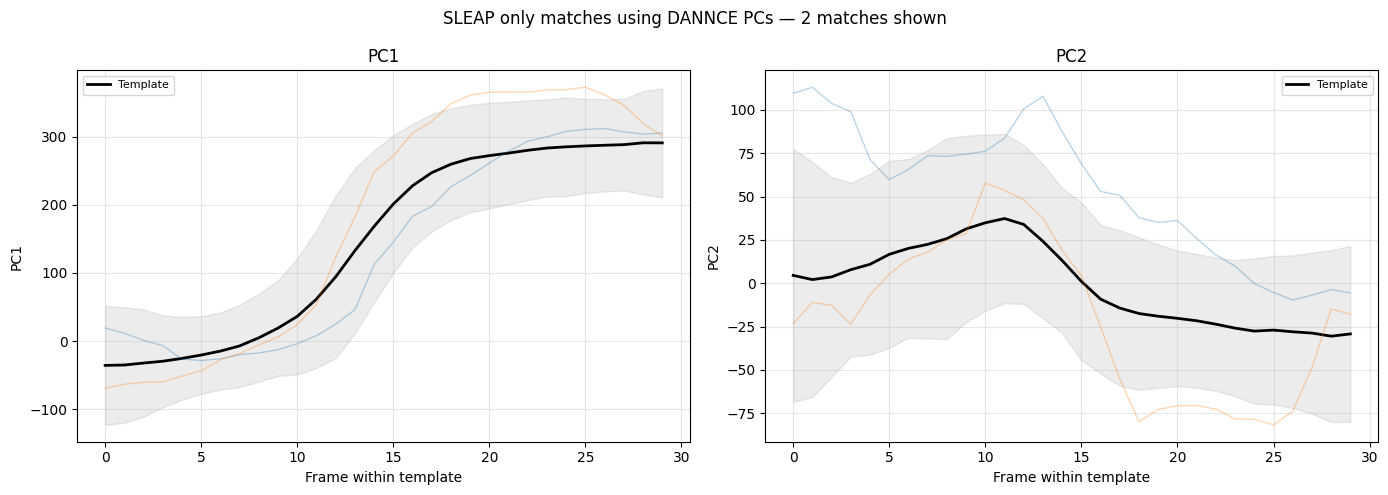

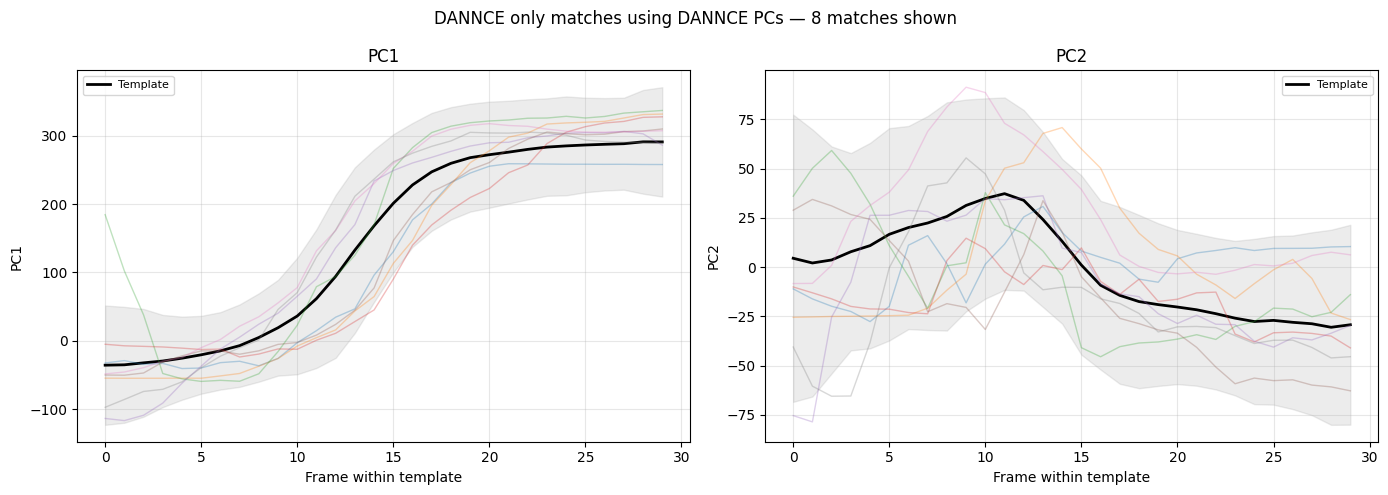

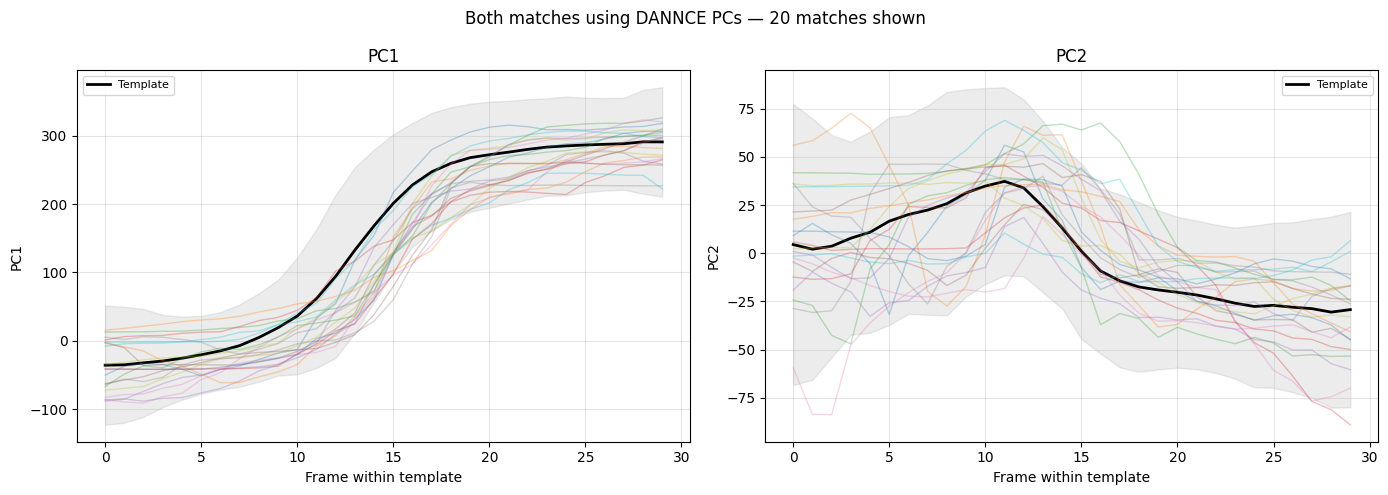

In [264]:
plot_template_matches(sleap_pcs, sleap_only, sleap_rebuild_template, sleap_rebuild_std*2,
                      n_components=n_components, title='SLEAP only matches using SLEAP PCs')

plot_template_matches(sleap_pcs, dannce_only, sleap_rebuild_template, sleap_rebuild_std*2,
                      n_components=n_components, title='DANNCE only matches using SLEAP PCs')

plot_template_matches(dannce_pcs, sleap_only, dannce_rebuild_template, dannce_rebuild_std*2,
                      n_components=n_components, title='SLEAP only matches using DANNCE PCs')

plot_template_matches(dannce_pcs, dannce_only, dannce_rebuild_template, dannce_rebuild_std*2,
                      n_components=n_components, title='DANNCE only matches using DANNCE PCs')

plot_template_matches(dannce_pcs, both, dannce_rebuild_template, dannce_rebuild_std*2,
                      n_components=n_components, title='Both matches using DANNCE PCs')


## Select starting template from motifs

In [265]:
new_template_data = template_data
new_template_data['pc_template'] = sleap_rebuild_template
new_template_data['bounds_to_use'] = sleap_rebuild_std*2
new_template_data['feature_means'] = feat_means
new_template_data['feature_stds'] = feat_std
new_template_data['pc_weights'] = pc_weights

np.savez(f'/home/yutaka-sprague/olveczky_lab/Lab/CLIRB/data/{rat}/{rat}_template_1.npz', **new_template_data)


In [215]:
template_data.keys()

dict_keys(['template', 'pc_weights', 'feature_means', 'feature_stds', 'bounds', 'pcs_to_use', 'temp_origin_file', 'temp_origin_idx', 'bounds_to_use', 'n_matches', 'match_sessions', 'match_starts', 'match_num_outside'])